# AlexNet

## Overview

AlexNet was introduced by Alex Krizhevsky, Ilya Sutskever, and Geoffrey Hinton in 2012. It won the ImageNet Large Scale Visual Recognition Challenge (ILSVRC) 2012 and demonstrated the power of deep convolutional neural networks for large-scale image classification.

## Key Features

- Uses ReLU activation instead of sigmoid or tanh.
- Introduced Dropout for regularization.
- Uses overlapping max pooling.
- Trained efficiently using GPUs.
- Much deeper than LeNet.

## Architecture Summary

Input Image
→ Convolution Layers
→ Max Pooling
→ Convolution Layers
→ Max Pooling
→ Fully Connected Layers
→ Output Layer

## Applications

- Image classification
- Object recognition
- Feature extraction
- Transfer learning

## Limitations

- Large number of parameters.
- Computationally expensive.
- Prone to overfitting without regularization.

In [14]:
import numpy as np
import pandas as pd

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Dense, Dropout, Flatten
from tensorflow.keras.preprocessing.image import ImageDataGenerator

import matplotlib.pyplot as plt
import sklearn

import warnings
warnings.filterwarnings('ignore')

In [15]:
train_dir = "HAR3Class/train"
test_dir = "HAR3Class/test"

train_datagen = ImageDataGenerator(
    rescale=1.0/255,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True)

test_datagen = ImageDataGenerator(rescale = 1.0/255)

train_data = train_datagen.flow_from_directory(
    train_dir,
    target_size = (224, 224),
    batch_size = 32, # no of images to be read at once
    class_mode = 'categorical'
) ## assigns labels based on folder names.


test_data = test_datagen.flow_from_directory(
    test_dir,
    target_size = (224, 224),
    batch_size = 32, # no of images to be read at once
    class_mode = 'categorical'
) 

## here if i put target_size = (227,227), then it will automatically resize the images, but not pad it

Found 610 images belonging to 3 classes.


Found 150 images belonging to 3 classes.


In [16]:
from keras import layers
def create_AlexNet(input_shape, num_classes):
    model = Sequential()

    # C1: 96 filters of size 11x11 with stride of 4x4, followed by a Max pooling (overlapping) layer of size 3x3 with stride of 2x2
    model.add(Conv2D(96, kernel_size = (11,11), strides = (4,4), activation = 'relu', input_shape=input_shape, padding = 'valid'))
    model.add(MaxPooling2D(pool_size = (3,3), strides = (2,2)))

    # C2: 256 filters of size 5x5 with stride of 1x1 and padding of 2, followed by a Max pooling (overlapping) layer of size 3x3 with stride of 2x2
    model.add(Conv2D(256, kernel_size = (5,5), strides = (1,1), activation = 'relu', padding='same'))
    model.add(MaxPooling2D(pool_size = (3,3), strides = (2,2)))

    # C3: 384 filters of size 3x3 with stride of 1x1 and padding of 1
    model.add(Conv2D(384, kernel_size = (3,3), strides = (1,1), activation = 'relu', padding = 'same'))

    # C4: 384 filters of size 3x3 with stride of 1x1 and padding of 1
    model.add(Conv2D(384, kernel_size = (3,3), strides = (1,1), activation = 'relu', padding = 'same'))
        
    # C5: 256 filters of size 3x3 with stride of 1x1 and padding of 1, followed by a max pooling layer of size 3x3 with stride of 2x2
    model.add(Conv2D(filters=256, kernel_size=(3, 3), strides=(1, 1), activation='relu', padding="same"))
    model.add(MaxPooling2D(pool_size = (3,3), strides = (2,2)))

    # flattening layer and fully connected layers 
    model.add(Flatten())
    model.add(Dense(4096, activation ='relu'))
    model.add(Dropout(0.5))
    model.add(Dense(4096, activation ='relu'))
    model.add(Dropout(0.5))
    model.add(Dense(num_classes, activation = 'softmax'))

    return model    

## padding takes only 2 values: valid / same. valid = no padding (output shrinks) and same = adds 0 around the edges (output same as input)

In [17]:
# Define the model input shape and number of output classes (3 classes in HAR3class)
input_shape = (224, 224, 3)
num_classes = 3

# Create the AlexNet model
alexnet_model = create_AlexNet(input_shape, num_classes)

# Display model summary
alexnet_model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d_10 (Conv2D)                   │ (None, 54, 54, 96)          │          34,944 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_6 (MaxPooling2D)       │ (None, 26, 26, 96)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_11 (Conv2D)                   │ (None, 26, 26, 256)         │         614,656 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_7 (MaxPooling2D)       │ (None, 12, 12, 256)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_12 (Conv2D)                   │ (None, 12, 12, 384)         │         885,120 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_13 (Conv2D)                   │ (None, 12, 12, 384)         │       1,327,488 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_14 (Conv2D)                   │ (None, 12, 12, 256)         │         884,992 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_8 (MaxPooling2D)       │ (None, 5, 5, 256)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_2 (Flatten)                  │ (None, 6400)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_6 (Dense)                      │ (None, 4096)                │      26,218,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_4 (Dropout)                  │ (None, 4096)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_7 (Dense)                      │ (None, 4096)                │      16,781,312 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_5 (Dropout)                  │ (None, 4096)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_8 (Dense)                      │ (None, 3)                   │          12,291 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 46,759,299 (178.37 MB)

 Trainable params: 46,759,299 (178.37 MB)

 Non-trainable params: 0 (0.00 B)

In [18]:
# Compiling the model
alexnet_model.compile(
    loss = 'categorical_crossentropy',
    optimizer = 'sgd',
    metrics = ['accuracy']
)

history = alexnet_model.fit(train_data, validation_data = test_data, epochs=10)

## sparse categorical crossentropy is for 0,1,2,3....
## categorical cross entropy is for one hot encoded variables

Epoch 1/10


 1/20 ━━━━━━━━━━━━━━━━━━━━ 2:22 7s/step - accuracy: 0.1562 - loss: 1.1250

 2/20 ━━━━━━━━━━━━━━━━━━━━ 34s 2s/step - accuracy: 0.2109 - loss: 1.1174 

 3/20 ━━━━━━━━━━━━━━━━━━━━ 33s 2s/step - accuracy: 0.2344 - loss: 1.1141

 4/20 ━━━━━━━━━━━━━━━━━━━━ 32s 2s/step - accuracy: 0.2461 - loss: 1.1123

...

17/20 ━━━━━━━━━━━━━━━━━━━━ 6s 2s/step - accuracy: 0.2986 - loss: 1.1017

18/20 ━━━━━━━━━━━━━━━━━━━━ 3s 2s/step - accuracy: 0.3008 - loss: 1.1016

19/20 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step - accuracy: 0.3027 - loss: 1.1014

20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.3043 - loss: 1.1012

20/20 ━━━━━━━━━━━━━━━━━━━━ 42s 2s/step - accuracy: 0.3361 - loss: 1.0977 - val_accuracy: 0.3333 - val_loss: 1.0965


<Axes: >

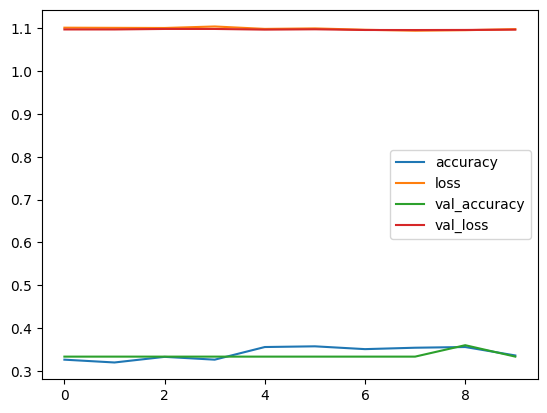

In [19]:
pd.DataFrame(history.history).plot()